Click-through rate for Version A: 0.1240
Click-through rate for Version B: 0.1480
T-statistic: -1.5657
P-value: 0.1176
The result is not statistically significant, meaning there is no significant difference between A and B.


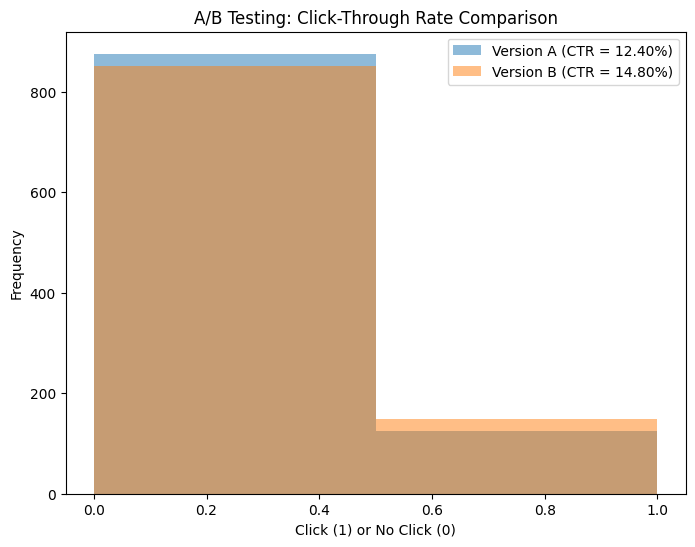

In [1]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import pandas as pd

# Step 1: Simulating Data
np.random.seed(42)  # For reproducibility

# Simulating a sample of 1,000 people for each email version (A and B)
n = 1000  # Sample size for each group

# Assume Version A has a 12% click-through rate
# Assume Version B has a 14% click-through rate
click_rate_A = 0.12
click_rate_B = 0.14

# Simulate user clicks (1 for click, 0 for no click) for each group
group_A_clicks = np.random.binomial(1, click_rate_A, n)
group_B_clicks = np.random.binomial(1, click_rate_B, n)

# Step 2: Analyzing the Results
# Calculate the average click-through rate for each group
ctr_A = group_A_clicks.mean()
ctr_B = group_B_clicks.mean()

# Perform a two-sample t-test to see if the difference in click-through rates is statistically significant
t_stat, p_value = stats.ttest_ind(group_A_clicks, group_B_clicks)

# Step 3: Display Results
print(f"Click-through rate for Version A: {ctr_A:.4f}")
print(f"Click-through rate for Version B: {ctr_B:.4f}")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

# Step 4: Interpretation of Results
if p_value < 0.05:
    print("The result is statistically significant, meaning there is a significant difference between A and B.")
else:
    print("The result is not statistically significant, meaning there is no significant difference between A and B.")

# Step 5: Visualize the Results
plt.figure(figsize=(8, 6))
plt.hist(group_A_clicks, bins=2, alpha=0.5, label='Version A (CTR = {:.2f}%)'.format(ctr_A * 100))
plt.hist(group_B_clicks, bins=2, alpha=0.5, label='Version B (CTR = {:.2f}%)'.format(ctr_B * 100))
plt.title('A/B Testing: Click-Through Rate Comparison')
plt.xlabel('Click (1) or No Click (0)')
plt.ylabel('Frequency')
plt.legend()
plt.show()

# Step 6: Save the Results to a DataFrame for Further Analysis
data = pd.DataFrame({
    'Group_A_Clicks': group_A_clicks,
    'Group_B_Clicks': group_B_clicks
})
data.to_csv('ab_test_results.csv', index=False)
